# Fine tune with Efficientnet

In [ ]:
!pip install keras_cv tensorflow_io

In [ ]:
import os, pathlib
from datetime import datetime
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel as PydanticBaseModel
import tensorflow as tf
print("tensorflow:", tf.__version__)
import keras_cv
print("keras_cv:", keras_cv.__version__)
import tensorflow_io as tfio
print("tfio:", tfio.__version__)
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

tensorflow: 2.18.0
keras_cv: 0.9.0


/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_util8EndsWithESt17basic_string_viewIcSt11char_traitsIcEES4_']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZN3tsl8str_util9LowercaseB5cxx11ESt17basic_s

tfio: 0.37.1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/drive/MyDrive/images_spectograms /content/

^C


In [ ]:
def obtener_spectogramas(ruta_base):
    data = []

    # Se listan las carpetas dentro de ruta_base
    image_db = os.listdir(ruta_base)
    image_db.sort()
    for i in image_db:
        ruta_db = os.path.join(ruta_base, i)
        #print("Procesando:", ruta_db)
        # Solo procesar si es un directorio
        if os.path.isdir(ruta_db):
            for img in os.listdir(ruta_db):
                ruta_img = os.path.join(ruta_db, img)
                # Verificar que sea un archivo (opcional)
                if os.path.isfile(ruta_img):
                    data.append({
                        "label": i,  # Se usa el nombre de la carpeta como etiqueta
                        "image_path": ruta_img
                    })
    return pd.DataFrame(data)

ruta_base = "/content/images_spectograms"
df = obtener_spectogramas(ruta_base)
print(df.shape)
df.head()

(1769, 2)


,label,image_path
0,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
1,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
2,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
3,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
4,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...


In [ ]:
df['label'].nunique()

3

In [ ]:
df.to_csv('/content/paths_spectograms.csv', index=False)

In [ ]:
strategy = tf.distribute.MirroredStrategy()
print("Strategy:", strategy)
print("Number of replicas:", strategy.num_replicas_in_sync)

Strategy: <tensorflow.python.distribute.mirrored_strategy.MirroredStrategy object at 0x7eb48fb6dd10>
Number of replicas: 1


In [ ]:
sorted(tf.config.list_logical_devices())

[LogicalDevice(name='/device:CPU:0', device_type='CPU')]

# Config

In [ ]:
from typing import Tuple
from pydantic import BaseModel

class Config(BaseModel):
    ## general
    run_ts: str = datetime.now().strftime("%Y-%d-%m %H:%M:%S")
    debug: bool = False
    model_name: str = "EfficientNetV2L"
    test_size: float = 0.3
    seed: int = 42
    fit_verbose: int = 1

    ## data
    dataset_dir: str = "/content/paths_spectograms.csv"
    path_data: str = "/content/paths_spectograms.csv"
    label: str = "label"
    n_label: int = 667
    img_size: Tuple[int, int] = (480, 480)
    channels: int = 1
    img_shape: Tuple[int, int, int] = (*img_size, channels)

    ## model
    base_model_weights: str = "imagenet"
    dropout: float = 0.20

    ## training
    label_smoothing: float = 0.05
    shuffle_size: int = 1028
    steps_per_epoch: int = 400
    batch_size: int = 128
    valid_batch_size: int = batch_size
    epochs: int = 100
    patience: int = 9
    monitor: str = "val_loss"  # val_loss
    monitor_mode: str = "auto"
    lr: float = 1e-4

    ## aug
    aug_proba: float = 0.8

# Crear una instancia de la configuración
cfg = Config()
cfg.dict()

<ipython-input-10-0eb5e6edc630>:43: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  cfg.dict()


{'run_ts': '2025-26-02 23:31:51',
 'debug': False,
 'model_name': 'EfficientNetV2L',
 'test_size': 0.3,
 'seed': 42,
 'fit_verbose': 1,
 'dataset_dir': '/content/paths_spectograms.csv',
 'path_data': '/content/paths_spectograms.csv',
 'label': 'label',
 'n_label': 667,
 'img_size': (480, 480),
 'channels': 1,
 'img_shape': (480, 480, 1),
 'base_model_weights': 'imagenet',
 'dropout': 0.2,
 'label_smoothing': 0.05,
 'shuffle_size': 1028,
 'steps_per_epoch': 400,
 'batch_size': 128,
 'valid_batch_size': 128,
 'epochs': 100,
 'patience': 9,
 'monitor': 'val_loss',
 'monitor_mode': 'auto',
 'lr': 0.0001,
 'aug_proba': 0.8}

# Preparation

## Load data

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
data = pd.read_csv(cfg.path_data)
data["path_img"] = data["image_path"]
if cfg.debug:
    data = data.iloc[:1000]
data.sample(6)
data.shape

(1769, 3)

## Dataset

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def show_img_stats(img):
    if isinstance(img, tf.Tensor):
        print((img.shape, img.dtype, img.numpy().min(), img.numpy().max()))
    elif isinstance(img, np.array):
        print((img.shape, img.dtype, img.min(), img.max()))
    else:
        print(f"unexpected type: {type(img)}")

def read_image(path_img):
    try:
        img_data = tf.io.read_file(path_img)
        img = tf.io.decode_jpeg(img_data, channels=cfg.channels)
        img = tf.image.resize(img, cfg.img_size)
        img = tf.cast(img, tf.float32)
        return img
    except tf.errors.InvalidArgumentError:
        return None


from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(data.label)

def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=cfg.n_label)

In [ ]:
from keras_cv.layers import BaseImageAugmentationLayer

class RandomRowMask(BaseImageAugmentationLayer):
    """
    Capa de augmentación que aplica máscaras en filas (time masking) a la imagen.

    Esta capa aplica un número aleatorio (entre 1 y max_num_mask) de máscaras en la dimensión
    temporal (filas) de la imagen usando la función tfio.audio.time_mask. Se utiliza tf.map_fn
    para vectorizar la operación en caso de que la entrada contenga un batch de imágenes.

    Args:
        param (int): Longitud máxima de la máscara a aplicar. Valor típico: 10.
        max_num_mask (int): Número máximo de máscaras a aplicar por imagen. Valor típico: 3.
    """

    def __init__(self, param=10, max_num_mask=3, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    @tf.function
    def augment_image(self, image, transformation=None, **kwargs):
        """
        Aplica máscaras en filas a la imagen.

        Args:
            image (tf.Tensor): Tensor de imagen de forma [altura, anchura, canales] o
                                [batch, altura, anchura, canales].
            transformation: Parámetro no usado, reservado para compatibilidad con la API.

        Returns:
            tf.Tensor: Imagen con las máscaras aplicadas, manteniendo la misma forma que la entrada.
        """
        # Función interna que procesa una sola imagen.
        def _apply_mask(img):
            # Asegurarse de que img tenga forma [H, W, C]
            img = tf.convert_to_tensor(img)
            original_shape = tf.shape(img)

            # Si la imagen tiene un canal único, podemos quitar la dimensión del canal para aplicar la máscara,
            # ya que tfio.audio.time_mask opera sobre tensores de 2 dimensiones.
            if original_shape[-1] == 1:
                img_2d = tf.squeeze(img, axis=-1)  # forma [H, W]
            else:
                img_2d = img  # Se asume que la función soporta la entrada directamente

            # Determinar el número de máscaras a aplicar (entre 1 y max_num_mask, inclusive).
            num_masks = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)

            # Aplicar la función de enmascarado de manera iterativa utilizando tf.range (esto se ejecuta dentro del gráfico)
            for _ in tf.range(num_masks):
                img_2d = tfio.audio.time_mask(img_2d, param=self.param)

            # Si se quitó la dimensión del canal, se la reincorpora para mantener la forma original.
            if original_shape[-1] == 1:
                img_2d = tf.expand_dims(img_2d, axis=-1)

            # Restaurar la forma original de la imagen (en caso de que se haya modificado)
            img_out = tf.reshape(img_2d, original_shape)
            return img_out

        # Si 'image' tiene batch dimension (4D) se aplica map_fn para procesar cada imagen individualmente.
        if tf.rank(image) == 4:
            image = tf.map_fn(_apply_mask, image)
        else:
            image = _apply_mask(image)
        return image

class RandomColumnMask(keras_cv.layers.BaseImageAugmentationLayer):
    def __init__(self, param=40, max_num_mask=2, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    def augment_image(self, image, transformation=None, **kwargs):
        num = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)

        def condition(i, img):
            return tf.less(i, num)

        def body(i, img):
            img = tfio.audio.freq_mask(tf.squeeze(img), param=self.param)
            img = tf.reshape(img, cfg.img_shape)
            return tf.add(i, 1), img

        _, image = tf.while_loop(
            condition,
            body,
            loop_vars=[0, image],
            shape_invariants=[tf.TensorShape([]), tf.TensorShape(cfg.img_shape)]
        )

        return image


augmenter = keras_cv.layers.Augmenter(
    layers=[
        keras_cv.layers.RandomBrightness(factor=0.2),
        #keras_cv.layers.RandomContrast(factor=0.2),
        keras_cv.layers.GridMask(ratio_factor=(0.05, 0.10)),
        keras_cv.layers.RandomGaussianBlur(kernel_size=2, factor=0.1),
        RandomRowMask(10, 3),
        RandomColumnMask(40, 2)
    ]
)

def augment_image(img):
    if tf.random.uniform([]) <= cfg.aug_proba:
        img = augmenter(img)
    return img

In [ ]:
def create_dataset(data, include_label=True, repeat=False, shuffle=False, augment=False, prefetch=False, batch_size=None):
    slices = data["path_img"].values
    read_func = read_image
    aug_func = augment_image
    if include_label:
        slices = slices, decode_label(data[cfg.label].values)
        read_func = lambda path_img, label: (read_image(path_img), label)
        aug_func = lambda img, label: (augment_image(img), label)
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(read_func, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if repeat: ds = ds.repeat()
    if shuffle: ds = ds.shuffle(buffer_size=cfg.shuffle_size)
    if augment: ds = ds.map(aug_func, num_parallel_calls=AUTOTUNE)
    if batch_size: ds = ds.batch(batch_size)
    if prefetch: ds = ds.prefetch(AUTOTUNE)
    return ds

In [ ]:
def create_training_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=True,
        shuffle=True,
        augment=True,
        prefetch=True,
        batch_size=cfg.batch_size,
    )

def create_validation_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=False,
        shuffle=False,
        augment=False,
        prefetch=True,
        batch_size=cfg.valid_batch_size,
    )

#### Check augmentation

In [ ]:
rec = data.sample(1).iloc[0]
rec

,93
label,Microrhopias quixensis
image_path,/content/images_spectograms/Microrhopias quixe...
path_img,/content/images_spectograms/Microrhopias quixe...


(TensorShape([480, 480, 1]), tf.float32, 2.1719131, 253.79572)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 246.0874)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 210.99097)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 221.49086)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 222.06339)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 227.47656)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 248.44785)


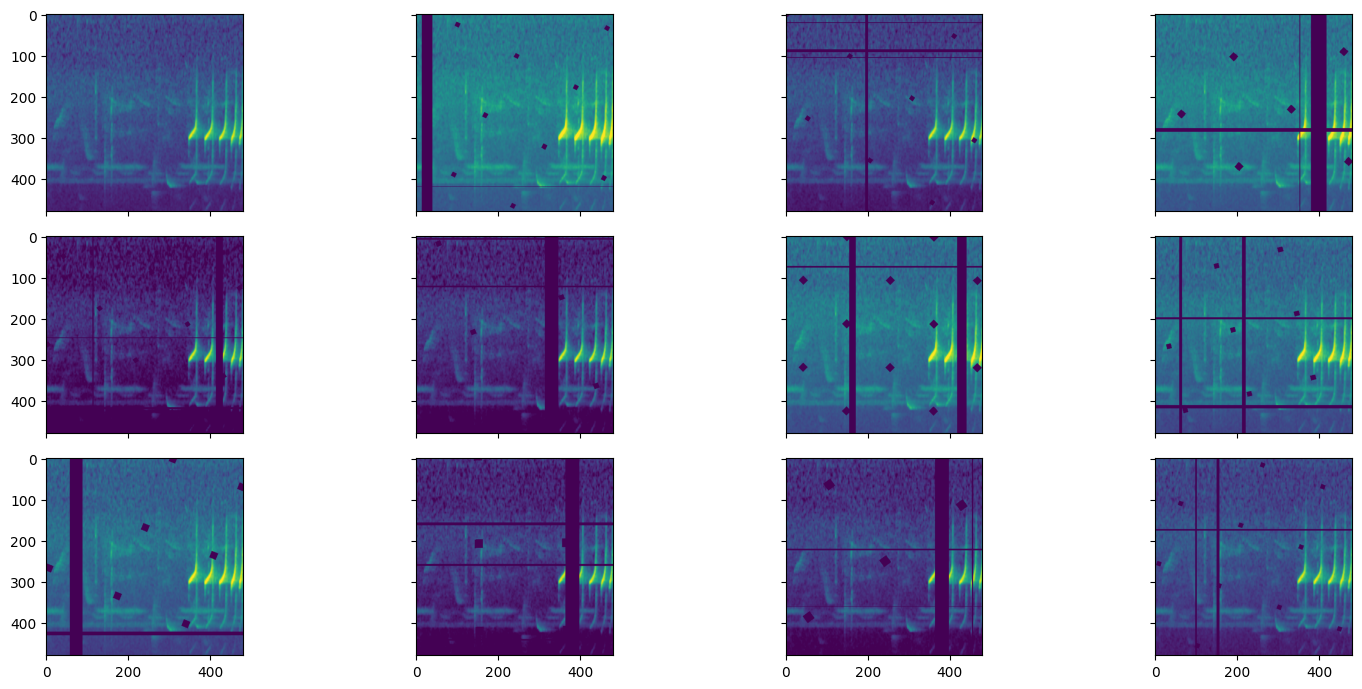

In [ ]:
img = read_image(rec.image_path)
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 7))
for i, ax in enumerate(axs.flat):
    if i == 0:
        ax.imshow(img, cmap='viridis')
        show_img_stats(img)
    else:
        img1 = augmenter(img)
        ax.imshow(img1, cmap='viridis')
        show_img_stats(img1)
plt.tight_layout()
plt.show()

#### Check dataset

In [ ]:
dev_data = data.sample(500)
dev_ds = create_training_dataset(dev_data)
dev_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 480, 480, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 667), dtype=tf.float32, name=None))>

In [ ]:
elem = next(iter(dev_ds.take(1)))
elem[1]

<tf.Tensor: shape=(128, 667), dtype=float32, numpy=
array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)>

(TensorShape([480, 480, 1]), tf.float32, 0.0, 207.40192)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 237.92198)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 242.56766)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 239.76819)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 227.76663)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 208.87476)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 253.50894)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 242.70755)
(TensorShape([480, 480, 1]), tf.float32, 0.0, 255.0)
(TensorShape([480, 480, 1]), tf.float32, 0.13434434, 253.78455)


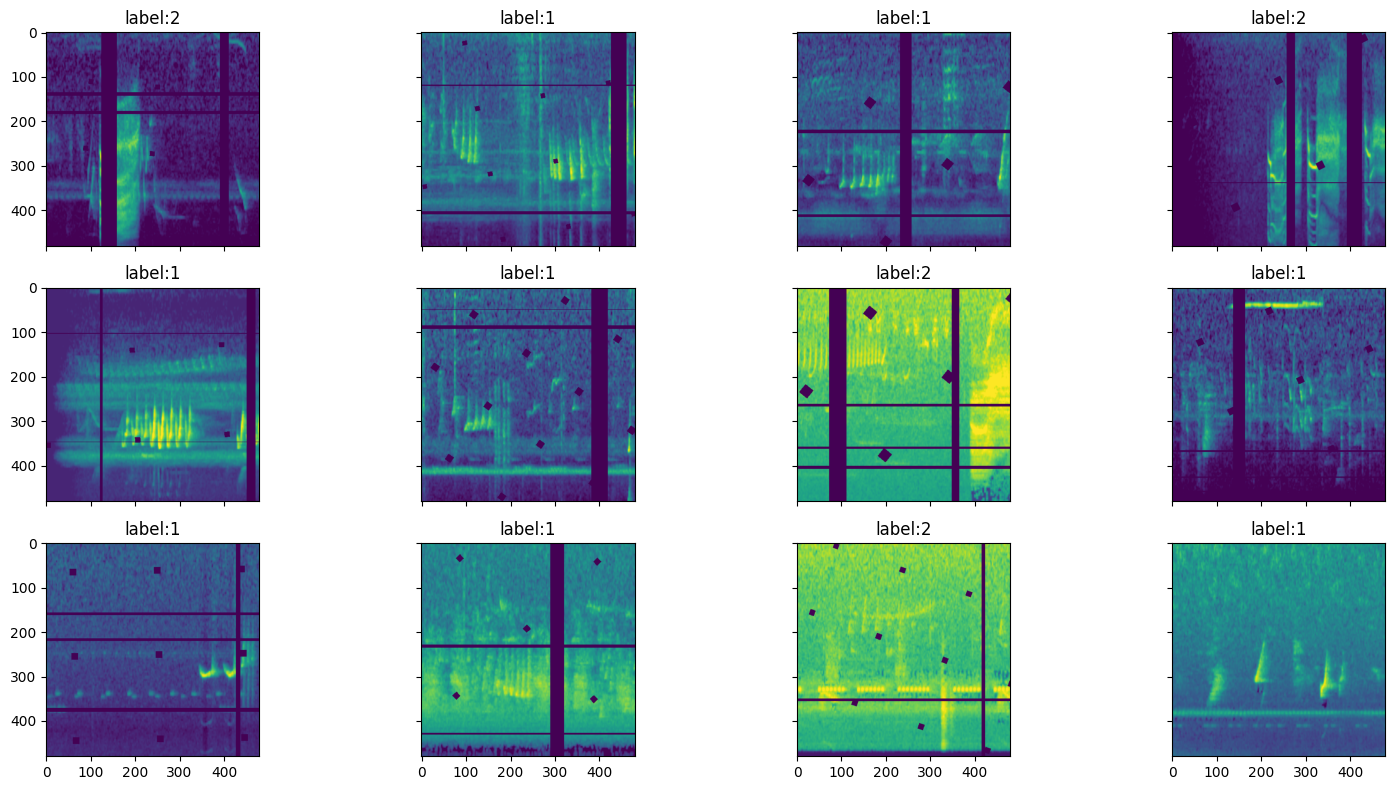

In [ ]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 8))
for i, ax in enumerate(axs.flat):
    img = elem[0][i]
    show_img_stats(img)
    ax.imshow(img, cmap="viridis")
    ax.set_title(f"label:{np.argmax(elem[1][i].numpy())}")
plt.tight_layout()
plt.show()

# Neural network

In [ ]:
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2L as BaseModel
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras import layers, losses, metrics, callbacks

In [ ]:
def convert_to_rgb(img):
    return tf.image.grayscale_to_rgb(img)

def create_model(lr, fine_tune_at=200):
    inputs = layers.Input(shape=cfg.img_shape, dtype=tf.float32, name="input_layer")
    x = layers.Lambda(convert_to_rgb, name="grayscale_to_rgb")(inputs)
    x = layers.Lambda(preprocess_input, name="preprocess_input")(x)
    base_model = BaseModel(include_top=False, weights=cfg.base_model_weights, pooling="avg")
    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_at]:
        layer.trainable = False
    x = base_model(x)
    x = layers.Dropout(cfg.dropout, name="top_dropout")(x)
    outputs = layers.Dense(cfg.n_label, name="logits")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=cfg.model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(
            from_logits=True, label_smoothing=cfg.label_smoothing
        ),
        metrics=['acc']
    )

    return model

#### Check model

In [ ]:
tf.keras.backend.clear_session()
with strategy.scope():
    dev_model = create_model(lr=cfg.lr)
dev_model.summary(line_length=120)

Model: "EfficientNetV2L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_layer (InputLayer)                            │ (None, 480, 480, 1)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ grayscale_to_rgb (Lambda)                           │ (None, 480, 480, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ preprocess_input (Lambda)                           │ (None, 480, 480, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ efficientnetv2-l (Functional)                       │ (None, 1280)                           │           117,746,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ top_dropout (Dropout)                               │ (None, 1280)                           │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ logits (Dense)                                      │ (None, 667)                            │               854,
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 118,601,275 (452.43 MB)

 Trainable params: 55,177,211 (210.48 MB)

 Non-trainable params: 63,424,064 (241.94 MB)

In [ ]:
dev_model.predict(dev_ds.take(1))

In [ ]:
dev_model.evaluate(dev_ds.take(1), return_dict=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - acc: 0.0000e+00 - loss: 6.5531


{'acc': 0.0, 'loss': 6.553104877471924}

# Training utils

In [ ]:
def get_callbacks(filepath):
    """Get callbacks"""
    cbs = [
        callbacks.ModelCheckpoint(
            filepath=filepath,
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            save_best_only=True,
            save_weights_only=True
        ),
        callbacks.EarlyStopping(
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            patience=cfg.patience,
            restore_best_weights=False,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', # O la métrica que prefieras
            factor=0.1, # Factor de reducción (ej: de 1e-4 a 1e-5)
            patience=3, # Número de épocas sin mejora antes de reducir
            verbose=1,
            mode='min', # O 'max', según la métrica
            min_lr=1e-7 # Learning rate mínimo
            )
    ]
    return cbs


def show_history(history):
    """Show history"""
    history_frame = pd.DataFrame(history.history)
    history_frame.index = pd.RangeIndex(1, len(history_frame) + 1, name="epoch")
    display(history_frame.style\
        .highlight_min(color='lightgreen', subset=['val_loss'])\
        .highlight_max(color='lightgreen', subset=['val_acc'])
    )
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    history_frame.loc[:, ['loss', 'val_loss']].plot(ax=ax[0], title='loss')
    history_frame.loc[:, ['acc', 'val_acc']].plot(ax=ax[1], title='acc')
    plt.tight_layout()
    plt.show()


def compute_oof(model, valid_df):
    """Compute OOF"""
    valid_ds = create_validation_dataset(valid_df)
    oof_pred = model.predict(valid_ds, verbose=False)
    oof_pred = pd.DataFrame(tf.nn.sigmoid(oof_pred).numpy(), index=valid_df.index)
    oof = pd.concat({"y_true": valid_df[cfg.label], "y_pred": oof_pred}, axis=1)
    return oof

In [ ]:
def run_training(train_df, valid_df, model_name):
    """Run training"""
    # prepare dataset
    train_ds = create_training_dataset(train_df)
    valid_ds = create_validation_dataset(valid_df)
    # create model
    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_model(lr=cfg.lr)
    # fit
    steps_per_epoch = cfg.steps_per_epoch
    print("steps_per_epoch:", steps_per_epoch)
    path_weight = f"/content/drive/MyDrive/model/weights_{model_name}.weights.h5"
    print("path_weights:", path_weight)
    hist = model.fit(
        train_ds,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_ds,
        callbacks=get_callbacks(path_weight),
        verbose=cfg.fit_verbose
    )
    # restore
    model.load_weights(path_weight)
    oof = compute_oof(model, valid_df)
    return hist, oof,model

# Run training
Let us start by training just a single split.

In [ ]:
data['label'].value_counts()

,count
label,
Microrhopias quixensis,998
Milvago chimachima,762
Acropternis orthonyx,731


In [ ]:
# seleccionar aleatoriamente 500 filas para las especies que superan las 500 muestras
df_sample = data.groupby('label').apply(lambda x: x.sample(500, random_state=42) if len(x) >500 else x).reset_index(drop=True)

<ipython-input-84-44ac036f7e17>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = data.groupby('label').apply(lambda x: x.sample(500, random_state=42) if len(x) >500 else x).reset_index(drop=True)


In [ ]:
train_df, valid_df = train_test_split(data, test_size=cfg.test_size, stratify=data[cfg.label])
valid_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df[cfg.label])
print(f"Split: {len(train_df)} vs {len(valid_df)} vs {len(test_df)}")
model_name = f"{cfg.model_name}"
print(f"model_name: {model_name}")

Split: 1238 vs 265 vs 266
model_name: EfficientNetV2L


In [ ]:
test_df.head()

,label,image_path,path_img
1430,Milvago chimachima,/content/images_spectograms/Milvago chimachima...,/content/images_spectograms/Milvago chimachima...
1227,Milvago chimachima,/content/images_spectograms/Milvago chimachima...,/content/images_spectograms/Milvago chimachima...
823,Microrhopias quixensis,/content/images_spectograms/Microrhopias quixe...,/content/images_spectograms/Microrhopias quixe...
868,Microrhopias quixensis,/content/images_spectograms/Microrhopias quixe...,/content/images_spectograms/Microrhopias quixe...
419,Microrhopias quixensis,/content/images_spectograms/Microrhopias quixe...,/content/images_spectograms/Microrhopias quixe...


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 1493 to 2374
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       374 non-null    object
 1   image_path  374 non-null    object
 2   path_img    374 non-null    object
dtypes: object(3)
memory usage: 11.7+ KB


In [ ]:
%%time
hist, oof, model = run_training(train_df, valid_df, model_name)

steps_per_epoch: 400
path_weights: /content/drive/MyDrive/model/weights_transfer_learn_simple.weights.h5
Epoch 1/80
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.0149 - loss: 6.3377
Epoch 1: val_loss improved from inf to 4.93741, saving model to /content/drive/MyDrive/model/weights_transfer_learn_simple.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 654s 2s/step - acc: 0.0149 - loss: 6.3369 - val_acc: 0.1515 - val_loss: 4.9374
Epoch 2/80
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.1455 - loss: 4.9185
Epoch 2: val_loss improved from 4.93741 to 3.97637, saving model to /content/drive/MyDrive/model/weights_transfer_learn_simple.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - acc: 0.1456 - loss: 4.9179 - val_acc: 0.2903 - val_loss: 3.9764
Epoch 3/80
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.2484 - loss: 4.2014
Epoch 3: val_loss improved from 3.97637 to 3.50166, saving model to /content/drive/MyDrive/model/weights_transfer_learn_simple.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 

,acc,loss,val_acc,val_loss
epoch,,,,
1,0.040391,5.993692,0.151527,4.937407
2,0.174805,4.697567,0.290322,3.976372
3,0.262715,4.098675,0.371894,3.501657
4,0.320684,3.754606,0.426947,3.215356
5,0.368379,3.495406,0.467036,3.019488
6,0.398730,3.320946,0.499690,2.865733
7,0.429531,3.170835,0.531074,2.717697
8,0.459922,3.026979,0.544086,2.631859
9,0.477266,2.922986,0.567414,2.529485


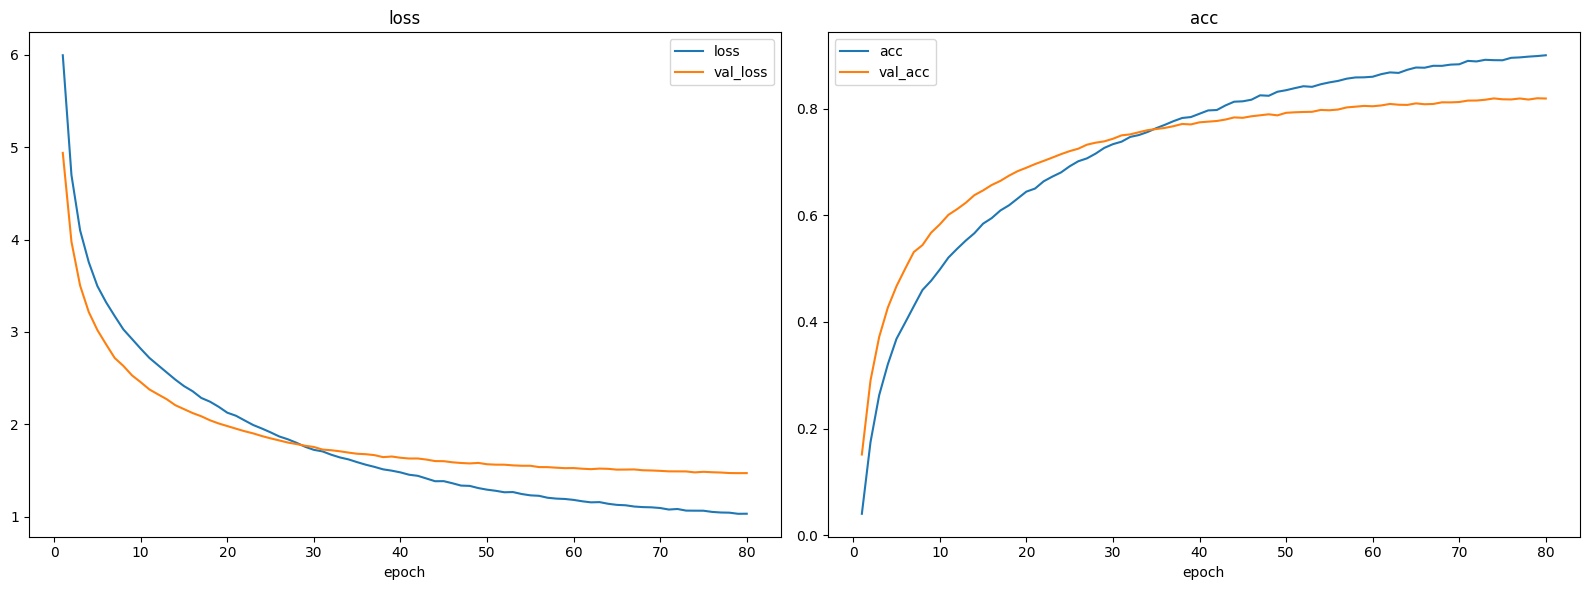

In [ ]:
show_history(hist)

In [ ]:
oof.to_csv("/content/drive/MyDrive/transfer_learn_simple.csv")

# Evaluation

In [ ]:
test_ds = create_validation_dataset(test_df)

In [ ]:
true_labels = []
i=0
test_ds_size = test_ds.cardinality().numpy()
print(test_ds_size)
for batch in test_ds:
    _, batch_labels = batch  # assuming that labels are the second element of the batch tuple
    true_labels.extend(batch_labels.numpy().tolist())
    i+=1

3


In [ ]:
pred_labels = model.predict(test_ds, verbose=cfg.fit_verbose)

253/253 ━━━━━━━━━━━━━━━━━━━━ 176s 695ms/step


In [ ]:
from sklearn.metrics import average_precision_score
mAP_score = average_precision_score(true_labels, pred_labels, average='macro')
average_precision = average_precision_score(true_labels, pred_labels)
print("Average Precision ", average_precision)
print("Macro average precision", mAP_score)

Average Precision  0.6678047622128377
Macro average precision 0.6678047622128377


In [ ]:
from sklearn.metrics import accuracy_score
true_label = np.array(true_labels)
true_label = np.argmax(true_labels, axis=1)

pred_label=tf.argmax(pred_labels, axis=1).numpy()
# # assume y_true and y_pred are your true and predicted labels, respectively
acc = accuracy_score(true_label, pred_label)
print(acc)

0.8187366399206915


In [ ]:
def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=cfg.n_label), integer_encoded

In [ ]:
_, tru_label = decode_label(data[cfg.label].values)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
precision = precision_score(true_label, pred_label, average='macro')
recall = recall_score(true_label, pred_label,  average='macro')
f1_score = f1_score(true_label, pred_label, average='macro')

print("Precision: ", precision)
print("Recall: ", recall)
print("F1_score: ", f1_score)

true_label_str = label_encoder.inverse_transform(true_label)
pred_label_str = label_encoder.inverse_transform(pred_label)

# classification_report
print(classification_report(true_label_str, pred_label_str))

Precision:  0.8235969481997978
Recall:  0.8119636126092747
F1_score:  0.8148584369008278
                                 precision    recall  f1-score   support

           Acropternis orthonyx       0.95      0.92      0.93        75
       Amblycercus holosericeus       0.81      0.78      0.79        27
           Ammodramus aurifrons       0.88      0.74      0.80        58
           Ammodramus humeralis       0.73      0.86      0.79        74
          Ammodramus savannarum       0.83      0.77      0.80        75
     Anabacerthia striaticollis       0.74      0.63      0.68        27
     Anabacerthia variegaticeps       0.75      0.75      0.75        44
              Anairetes parulus       0.81      0.72      0.76        36
          Andigena nigrirostris       0.83      0.87      0.85        63
       Anisognathus igniventris       0.83      0.85      0.84        34
        Anisognathus lacrymosus       0.81      0.81      0.81        26
        Anisognathus somptuosus   

In [ ]:
import pickle
with open(f"/content/drive/MyDrive/model/label_encoder_{model_name}.pkl", "wb") as f:
    pickle.dump(label_encoder, f)